Feature scaling is the last part of feature engineering you just do it before giving your data to the machine

In [ ]:
# Feature Scalling is a technique to standardize the input fetures present in the data in a fixed range
# input features
# target variable 

In [ ]:
# feature Scaling means aik given range ke nadar features ko le ana
# Feature Scaling has 2 techniques
# 1. Standardization
# 2. Normalization

### Normalization

In [ ]:
  # weight # machine learning literature me yh bola jata hai ke ap jab bhi numerical quantities ke sath deal kr rhe ho to
# its always a good idea to remove the unit aik commn scale pr le le aao aur sif magnitude ko consider kro

Normaliztion has few tecniques
* minmax scaling
* mean normalization (You are doing mean centring(-1 to 1)) when you do centered data you normaly use standardization instead
* max absolute scalling (spars data when you hAVE SO MANY ZEROS)
* robust scalling (apply this to your data if you have outliers)


Minmax scalling

xi=xi(original value)-xmin/xmax-xmin
* scaled distribution will be between 0 and 1 (means 0 se 1 ke beech me squish kr de rhe ho)

In [8]:
import numpy as np
weight=np.array([50,20,70,80,10,15])
max_value=max(weight)
min_value=min(weight)
normalized_weight=[]
for i in weight:
    normalized_weight.append((i-min_value)/(max_value-min_value))

<Axes: >

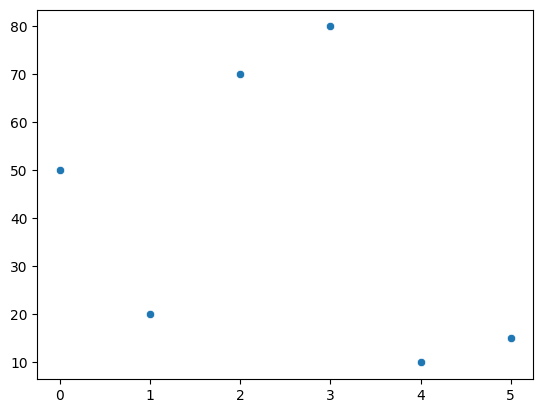

In [9]:
import seaborn as sns
sns.scatterplot(weight)

<Axes: >

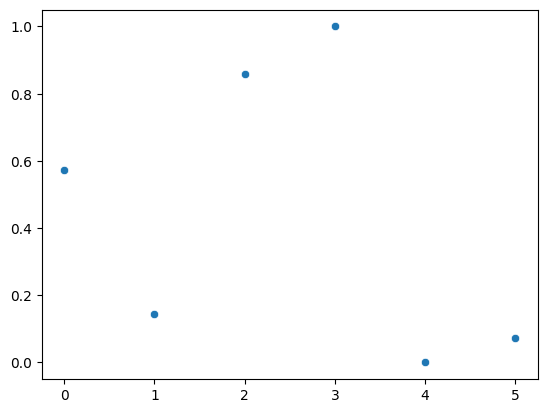

In [10]:
sns.scatterplot(normalized_weight)

In [2]:
import numpy as np
import pandas as pd #data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("WineQT.csv", usecols=[0,1,2])
df.columns=["Class label", "Alcohol", "Malic acid"] #output columns next 2 are imput columns


,Class label,Alcohol,Malic acid
0,7.4,0.700,0.00
1,7.8,0.880,0.00
2,7.8,0.760,0.04
3,11.2,0.280,0.56
4,7.4,0.700,0.00
...,...,...,...
1138,6.3,0.510,0.13
1139,6.8,0.620,0.08
1140,6.2,0.600,0.08
1141,5.9,0.550,0.10


distplot is the pdf plot

<Axes: xlabel='Alcohol', ylabel='Density'>

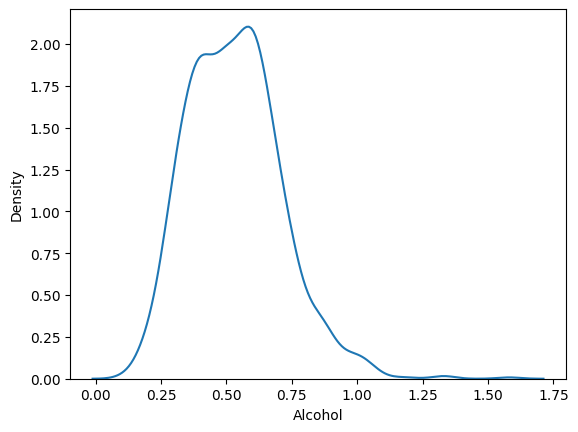

In [18]:
# sns.displot(df["Alcohol"])
sns.kdeplot(df["Alcohol"])

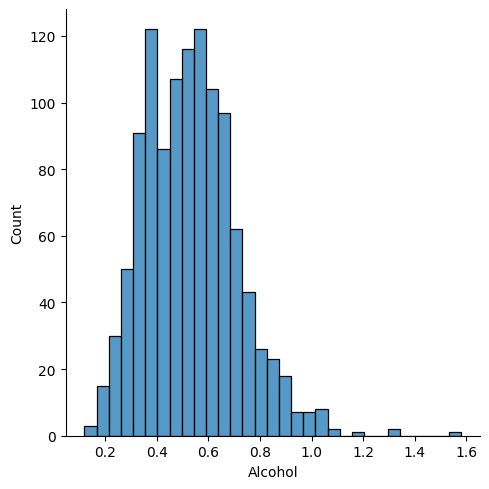

In [19]:
sns.displot(df["Alcohol"])

In [20]:
# when you do scalling you have to do a train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(df.drop('Class label', axis=1),
                                                  df["Class label"],
                                                  test_size=0.3,
                                                  random_state=0)
X_test.shape, X_test.shape

((343, 2), (343, 2))

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# fit the scaler to train test it will learn th oarameters
scaler.fit(X_train)
# transform the train and test the sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_train_scaled= pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled= pd.DataFrame(X_test_scaled, columns=X_test.columns)  

In [23]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,800.0,800.0
mean,0.3,0.3
std,0.1,0.2
min,0.0,0.0
25%,0.2,0.1
50%,0.3,0.3
75%,0.4,0.5
max,1.0,1.0


<function matplotlib.pyplot.show(close=None, block=None)>

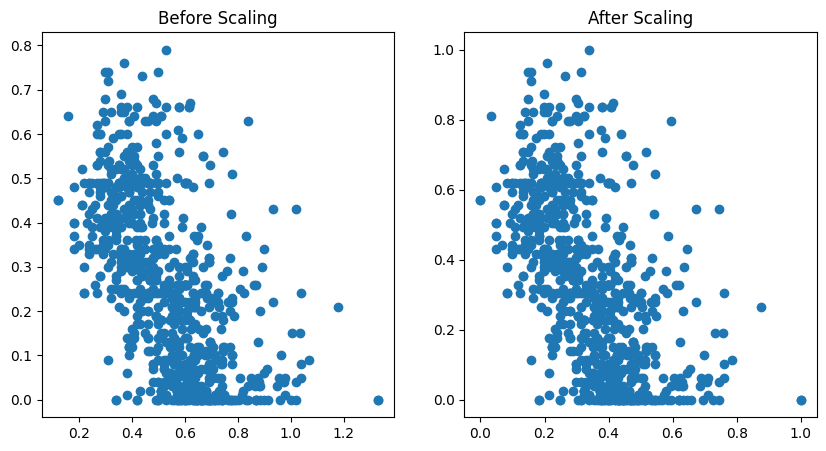

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.scatter(X_train["Alcohol"], X_train["Malic acid"])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Alcohol"], X_train_scaled["Malic acid"])
ax2.set_title("After Scaling")
plt.show